# Wider base density + stronger tilt — FLUX.1-dev at guidance 1.5, m = 5

Follow-up to [`../flux_lambda_sweep/`](../flux_lambda_sweep/flux_lambda_sweep_results.ipynb) (job 693836),
which validated the pipeline end to end but produced no visibly novel samples.

**What the baseline showed.** Six λ_eff rows in 111 min, $E_{q}[f]$ rising monotonically
$1.0055 \to 1.0488$, and decoded images that were clean, on-prompt dogs at *every* level including the most
tilted. The adapter is therefore correct (settled — this notebook drops the go/no-go gate), but the tilt did
not bite hard enough to matter visually.

Worth being precise about what "+4.3%" meant, since it is easy to misread as "the tilt did nothing": with
$\operatorname{std}_{p}(f) = 0.0203$, that shift is **≈ 2.1 standard deviations** of $f$ under $p$ — roughly
what m=3 should deliver. The tilt worked; 2σ in *this* reward simply does not correspond to visible novelty.

## Two changes, and why both

| | baseline | here |
|---|---|---|
| `GUIDANCE` | 3.5 | **1.5** |
| `M_TILT` (λ_max = m·λ_s) | 3 | **5** |
| `MAX_SWEEPS` | 16 | **24** |
| `--time` | 420 min | **360 min** |
| R / N_GAMMA / NUM_EPS, N, ess_target, seed, prompt, n_steps, IMG | | *unchanged* |

**`GUIDANCE` is the important one.** CLAUDE.md records that **SMC cannot escape the generator manifold** —
particles are $x = G(z)$, so the tilt can only move within whatever $p$ is. At guidance 3.5 with prompt
`"A dog"`, that manifold *is* "ordinary dog photographs", and **no value of λ can produce a non-dog**. Lowering
guidance widens $p$ and gives the tilt somewhere to go. It also costs nothing: guidance is an embedding, not a
second forward pass.

**`M_TILT = 5`** because $\lambda \cdot \operatorname{std}_{p}(f) = m$, so m *is* tilt strength in σ units;
5σ against the baseline's 2.1σ. **`MAX_SWEEPS = 24`** because the baseline hit the *cap* at both hard levels
(β = 0.77, 1.0) where acceptance collapsed to 0.13–0.17 — a stronger tilt mixes worse, so 16 would be less
adequate, not more.

### The confound, stated plainly

Changing two variables means a **positive** result is ambiguous — more novelty could come from the wider $p$ or
from the stronger tilt. A **negative** result is clean: if a wider $p$ *and* 5σ still yields ordinary dogs,
both hypotheses take damage.

The confound is partly resolvable after the fact: **row 0 (λ_eff = 0) is untilted**, so comparing it against
the baseline's row 0 shows exactly what guidance did to $p$, independent of any tilt. If row 0 is no longer
recognisably dogs, guidance went too far and $p$ was widened past usefulness.

### Expect truncation — that is accepted, not ignored

m=5 at cap 24 needs ≈ 8.3 levels (≈ 200 sweeps) to reach β=1, but 6 h buys ≈ 153 sweeps. So this run should
stop near **β ≈ 0.77, i.e. λ_eff ≈ 3.9σ**, with roughly 6–7 levels. That is handled: the kernel checkpoints
every sweep and stops cleanly at a deadline, and the cells below render whatever levels completed.
`--time=480` would reach β=1 if the extra two hours are ever worth spending.

In [1]:
import math
import os
import sys
import time

import matplotlib.pyplot as plt
import torch

T_START = time.time()

REPO = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if not os.path.isdir(os.path.join(REPO, "creativity_measure")):
    REPO = os.path.abspath(os.path.join(os.getcwd(), ".."))
if REPO not in sys.path:
    sys.path.insert(0, REPO)
SWEEP_DIR = os.path.join(REPO, "notebooks", "flux_lambda_sweep_strong")
os.makedirs(SWEEP_DIR, exist_ok=True)

# --- wall clock -----------------------------------------------------------------------------------
# The SMC is one long library call, so it cannot be interrupted from outside; the kernel checks
# DEADLINE after every sweep instead. RESERVE_H is held back for decoding and rendering.
# Under Slurm, SLURM_JOB_END_TIME is the job's real end, so the deadline tracks --time automatically.
#
# This run is EXPECTED to hit the deadline: m=5 at cap 24 needs ~200 sweeps to reach beta=1 and 6 h
# buys ~153, so expect to stop near beta ~ 0.77. Truncation is safe -- every level is on disk.
WALL_BUDGET_H = 6.0            # keep in sync with --time in flux_strong_tilt.slurm (360 min)
RESERVE_H = 0.75               # held back for VAE decoding, rendering, and writing the notebook
try:
    _end = float(os.environ["SLURM_JOB_END_TIME"])
except (KeyError, ValueError):
    _end = None
if _end and _end > T_START:
    DEADLINE, WALL_BUDGET_H, _src = _end - RESERVE_H * 3600, (_end - T_START) / 3600, "SLURM"
else:
    DEADLINE, _src = T_START + (WALL_BUDGET_H - RESERVE_H) * 3600, "constant"

from creativity_measure import set_default_dtype

set_default_dtype(torch.float32)          # FLUX runs bf16; everything the SMC touches is fp32
torch.manual_seed(0)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.bfloat16

from huggingface_hub import auth_check

auth_check("black-forest-labs/FLUX.1-dev")
print(f"device {DEVICE} ({DTYPE})   budget {WALL_BUDGET_H:.2f} h via {_src}")
print(f"SMC deadline {time.strftime('%H:%M:%S', time.localtime(DEADLINE))}")
print("FLUX.1-dev access: OK")

/home/dcor/arielzoizner/miniconda3/envs/creativity-measure/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device cuda (torch.bfloat16)   budget 6.00 h via SLURM
SMC deadline 18:53:29
FLUX.1-dev access: OK


In [2]:
from diffusers import FluxPipeline

MODEL_ID = "black-forest-labs/FLUX.1-dev"
PROMPT = "A dog"

# GUIDANCE is the headline change: 1.5 vs the baseline's 3.5.
# FLUX.1-dev is guidance-distilled, so the scale is an additive EMBEDDING (added to the timestep
# embedding), not a second CFG forward pass -- lowering it costs nothing.
#
# It defines the base density p, and therefore the manifold the tilt is confined to: CLAUDE.md records
# that SMC cannot escape the generator manifold, since particles are x = G(z). At 3.5 with prompt
# "A dog" that manifold is "ordinary dog photographs" and NO lambda can leave it. 1.5 widens p.
#
# Trade-off to watch: lower guidance means weaker prompt adherence and somewhat lower fidelity. Row 0
# (lambda_eff = 0) is untilted, so it shows directly what this did to p -- if row 0 is no longer
# recognisably dogs, p has been widened past usefulness.
GUIDANCE = 1.5

# Latent geometry. Defined here (not in the adapter cell) because `decode` below needs it.
IMG = 512
C, H, W = 16, IMG // 8, IMG // 8       # VAE downsamples 8x; FLUX latents have 16 channels
LATENT_DIM = C * H * W                 # 65536  (1024^2 would be 262144, and pCN mixes worse)

pipe = FluxPipeline.from_pretrained(MODEL_ID, torch_dtype=DTYPE).to(DEVICE)
with torch.no_grad():
    prompt_embeds, pooled_prompt_embeds, text_ids = pipe.encode_prompt(
        prompt=PROMPT, prompt_2=None, device=DEVICE, max_sequence_length=512
    )
# Free both text encoders (~9.5 GB, T5 dominates): the embeddings above are all we need.
pipe.text_encoder = pipe.text_encoder_2 = pipe.tokenizer = pipe.tokenizer_2 = None
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()
transformer, vae = pipe.transformer.eval(), pipe.vae.eval()
VAE_SF, VAE_SHIFT = vae.config.scaling_factor, vae.config.shift_factor
print(f"loaded; guidance={GUIDANCE} (baseline used 3.5)  "
      f"guidance_embeds={transformer.config.guidance_embeds}")
print(f"latents ({C}, {H}, {W}) = d {LATENT_DIM}  vae scaling={VAE_SF} shift={VAE_SHIFT}")


def decode(flat: torch.Tensor, chunk: int = 2) -> torch.Tensor:
    """Flat FLUX latents (B, d) -> images (B, 3, 512, 512) in [0, 1].

    Chunked because the VAE decoder, not the transformer, is the memory spike.
    """
    outs = []
    for i in range(0, flat.shape[0], chunk):
        lat = flat[i : i + chunk].reshape(-1, C, H, W).to(DEVICE, DTYPE) / VAE_SF + VAE_SHIFT
        with torch.no_grad():
            img = vae.decode(lat).sample
        outs.append(pipe.image_processor.postprocess(img.float(), output_type="pt").cpu())
    return torch.cat(outs)


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]


Loading checkpoint shards: 100%|██████████| 3/3 [00:00<00:00, 55.25it/s]



Loading pipeline components...:  29%|██▊       | 2/7 [00:00<00:00, 15.46it/s]


Loading pipeline components...:  71%|███████▏  | 5/7 [00:00<00:00, 22.39it/s]


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]


Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00, 88.09it/s]


You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers



Loading pipeline components...: 100%|██████████| 7/7 [00:00<00:00, 14.84it/s]

loaded; guidance=1.5 (baseline used 3.5)  guidance_embeds=True
latents (16, 64, 64) = d 65536  vae scaling=0.3611 shift=0.1159


In [3]:
from creativity_measure.distances.edm_adapter import edm_score_fn
from creativity_measure.generators.base import edm_generator

SIGMA_MIN, SIGMA_MAX = 2e-3, 80.0
N_STEPS = 8               # Heun ODE steps inside G (15 denoiser evals: 2/step, minus the last corrector)

# Both must be 2-D in diffusers 0.39; _prepare_latent_image_ids takes the *packed* (half) grid.
img_ids = FluxPipeline._prepare_latent_image_ids(1, H // 2, W // 2, DEVICE, DTYPE)
txt_ids = text_ids if text_ids.ndim == 2 else text_ids[0]


def denoiser(x: torch.Tensor, sigma: torch.Tensor) -> torch.Tensor:
    """EDM denoiser D(x_sigma, sigma) = E[X | x_sigma] backed by the FLUX transformer.

    Flow matching interpolates, EDM adds:  x_t = (1-t)x_0 + t*eps  vs  x_sigma = x_0 + sigma*eps.
    Factoring out (1-t) makes them identical under  t = sigma/(1+sigma),  x_t = x_sigma/(1+sigma).
    FLUX predicts v = eps - x_0, so  x_t - t*v = x_0  exactly -- no approximation.
    Validated by the baseline run: its lambda_eff=0 row decoded to clean, on-prompt images.

    At sigma=80, t = 80/81 ~ 0.988 and x_t ~ z -- unit-scale noise, which is what FLUX expects at
    t -> 1, so sigma_max=80 is the natural choice for these unit-variance latents.

    Returns fp32 (the transformer runs bf16): reward.x_refs pins dtype for the whole SMC, and bf16
    weight/ESS arithmetic would quietly corrupt the beta schedule.
    """
    b = x.shape[0]
    sig = sigma.reshape(b, 1, 1, 1).to(torch.float32)
    t = (sigma / (1.0 + sigma)).to(torch.float32)
    x_t = x.to(torch.float32) / (1.0 + sig)
    packed = FluxPipeline._pack_latents(x_t.to(DTYPE), b, C, H, W)
    with torch.no_grad():
        v = transformer(
            hidden_states=packed,
            timestep=t.to(DTYPE),                                   # forward() scales by 1000 itself
            guidance=torch.full((b,), GUIDANCE, device=x.device, dtype=torch.float32),
            pooled_projections=pooled_prompt_embeds.expand(b, -1).to(DTYPE),
            encoder_hidden_states=prompt_embeds.expand(b, -1, -1).to(DTYPE),
            txt_ids=txt_ids,
            img_ids=img_ids,
            return_dict=False,
        )[0]
    v = FluxPipeline._unpack_latents(v, IMG, IMG, 8).to(torch.float32)
    return (x_t - t.reshape(b, 1, 1, 1) * v).to(torch.float32)


G = edm_generator(denoiser, img_shape=(C, H, W), sigma_min=SIGMA_MIN,
                  sigma_max=SIGMA_MAX, n_steps=N_STEPS)
score_fn = edm_score_fn(denoiser, (C, H, W))
print(f"generator + score ready   sigma in [{SIGMA_MIN}, {SIGMA_MAX}]  n_steps={N_STEPS}")

generator + score ready   sigma in [0.002, 80.0]  n_steps=8


In [4]:
from creativity_measure import SquaredGlobalIEMDistance
from creativity_measure.tilt import NormalizedExpectedDistanceReward

# --- knobs ----------------------------------------------------------------------------------------
# IEM knobs held at the baseline's values on purpose: reward fidelity is a THIRD candidate explanation
# for the weak baseline result, and the auto-R diagnostic is measuring it separately. The Brownian bank
# is seeded, so these do not make f stochastic -- they make it a coarser approximation of the true IEM
# distance (we sample correctly from a slightly different target).
R, N_GAMMA, NUM_EPS = 4, 6, 3
N = 8
MAX_SWEEPS = 24    # baseline hit the CAP at both hard levels (beta 0.77, 1.0) where acceptance fell to
                   # 0.13-0.17; a stronger tilt mixes worse, so 16 would be less adequate, not more.
M_TILT = 5.0       # tilt strength in sigma units, since lambda * std_p(f) = m. Baseline reached 2.1
                   # sigma at m=3 and still gave ordinary dogs; this targets 5 sigma.
ESS_TARGET = 0.85
SEED = 101

gen = torch.Generator(device="cpu").manual_seed(7)
with torch.no_grad():
    latent_refs = G(torch.randn(R, LATENT_DIM, generator=gen).to(DEVICE))

S = latent_refs.std().item()
GAMMA_LO = max(1.0 / S**2, 1.0 / SIGMA_MAX**2)      # from the DATA scale, not sigma_max (pure noise)
GAMMA_HI = min(2.0**10, 1.0 / SIGMA_MIN**2)         # both clamped to the denoiser's valid range
GAMMAS = torch.logspace(math.log2(GAMMA_LO), math.log2(GAMMA_HI), N_GAMMA, base=2).to(DEVICE)
D2 = SquaredGlobalIEMDistance(None, GAMMAS, num_eps=NUM_EPS, seed=123, score_fn=score_fn)

t0 = time.time()
reward = NormalizedExpectedDistanceReward(distance=D2, x_refs=latent_refs)   # pays the R x R term
t_norm = time.time() - t0
print(f"refs {tuple(latent_refs.shape)}  S={S:.3f}  gamma=[{GAMMA_LO:.3g}, {GAMMA_HI:.3g}]"
      f" x {N_GAMMA}   normalizer {t_norm:.0f}s")
print(f"(baseline at guidance 3.5 had S=1.000-ish; a wider p may shift both S and std_p(f))")

# --- lambda scale ---------------------------------------------------------------------------------
# lam_s = 1/std_p(f), so m = lambda * std_p(f) is tilt strength in units of f's spread under p. This
# parameterisation is what makes m comparable ACROSS guidance settings: lam_s is recomputed from the
# new (wider) p, so "m=5" means 5 sigma of the new f, not of the baseline's.
# std(f) from 8 samples carries ~27% relative error, so LAM_MAX is order-of-magnitude.
t0 = time.time()
with torch.no_grad():
    f_probe = reward(G(torch.randn(N, LATENT_DIM, generator=gen).to(DEVICE)))
t_sweep = time.time() - t0
f_std = float(f_probe.std())
lam_s = (1.0 / f_std) if f_std > 0 else float("inf")
LAM_MAX = M_TILT * lam_s
print(f"\nsweep-equivalent (G + reward) on batch {N}: {t_sweep:.0f}s "
      f"(baseline measured 115 s)")
print(f"f ~ p: mean={float(f_probe.mean()):.4f} std={f_std:.4f} "
      f"range=[{float(f_probe.min()):.4f}, {float(f_probe.max()):.4f}]")
print(f"  baseline at guidance 3.5: mean=1.0055 std=0.0203 -> a LARGER std here means the wider p")
print(f"  already spreads f more, which is itself evidence guidance was the constraint.")
print(f"lambda_s = {lam_s:.2f}   LAM_MAX = {M_TILT:.0f} * lambda_s = {LAM_MAX:.1f}")

print(f"\n{'m':>5} {'lambda':>10} {'ESS/N':>7}   (one-shot IS from p to q_lambda)")
for m in (1.0, 3.0, M_TILT, 10.0, 30.0):
    w = torch.softmax(m * lam_s * f_probe, dim=0)
    print(f"{m:5.0f} {m * lam_s:10.1f} {float(1.0 / (w.pow(2).sum() * N)):7.2f}"
          + ("   <- this run" if m == M_TILT else "   <- baseline" if m == 3.0 else ""))

# --- cost note (report only; the deadline handles overrun by stopping cleanly) ---------------------
# Levels needed to reach beta=1 scale as ~m/c with c ~ 0.6 calibrated on the baseline (m=3 took 5
# beta-steps). So m=5 wants ~8.3 levels; at cap 24 that is ~200 sweeps, and 6 h buys ~153.
# TRUNCATION IS EXPECTED -- around beta ~ 0.77, i.e. lambda_eff ~ 3.9 sigma, with 6-7 levels.
per_level_min = t_sweep * MAX_SWEEPS / 60
budget_min = (WALL_BUDGET_H - RESERVE_H) * 60 - (time.time() - T_START) / 60
afford = budget_min / per_level_min
need = M_TILT / 0.6
print(f"\nper level at cap {MAX_SWEEPS}: {per_level_min:.1f} min")
print(f"budget buys ~{afford:.1f} levels; reaching beta=1 needs ~{need:.1f}")
if afford < need:
    print(f"  -> EXPECT TRUNCATION at beta ~ {min(1.0, afford / need):.2f}, i.e. lambda_eff ~ "
          f"{M_TILT * min(1.0, afford / need):.1f} sigma. Every completed level is saved.")
else:
    print("  -> should reach beta = 1")

refs (4, 65536)  S=1.026  gamma=[0.95, 1.02e+03] x 6   normalizer 75s
(baseline at guidance 3.5 had S=1.000-ish; a wider p may shift both S and std_p(f))



sweep-equivalent (G + reward) on batch 8: 165s (baseline measured 115 s)
f ~ p: mean=0.9886 std=0.0039 range=[0.9836, 0.9939]
  baseline at guidance 3.5: mean=1.0055 std=0.0203 -> a LARGER std here means the wider p
  already spreads f more, which is itself evidence guidance was the constraint.
lambda_s = 254.07   LAM_MAX = 5 * lambda_s = 1270.3

    m     lambda   ESS/N   (one-shot IS from p to q_lambda)
    1      254.1    0.56
    3      762.2    0.28   <- baseline
    5     1270.3    0.25   <- this run
   10     2540.7    0.24
   30     7622.0    0.20

per level at cap 24: 65.8 min
budget buys ~4.7 levels; reaching beta=1 needs ~8.3
  -> EXPECT TRUNCATION at beta ~ 0.57, i.e. lambda_eff ~ 2.8 sigma. Every completed level is saved.


In [5]:
from creativity_measure import LevelSnapshot, PCNKernel, adaptive_tempering_smc_sample

CONFIG = {
    "model_id": MODEL_ID, "img": IMG, "C": C, "H": H, "W": W, "latent_dim": LATENT_DIM,
    "vae_scaling_factor": VAE_SF, "vae_shift_factor": VAE_SHIFT,
    "N": N, "m_tilt": M_TILT, "lam_max": LAM_MAX, "lam_s": lam_s, "ess_target": ESS_TARGET,
    "n_mcmc": None, "max_n_mcmc": MAX_SWEEPS, "seed": SEED, "prompt": PROMPT,
    "guidance": GUIDANCE, "n_steps": N_STEPS, "sigma_min": SIGMA_MIN, "sigma_max": SIGMA_MAX,
    "R": R, "n_gamma": N_GAMMA, "num_eps": NUM_EPS,
    "t_norm_s": t_norm, "t_sweep_s": t_sweep,
}
PARTIAL_CKPT = os.path.join(SWEEP_DIR, f"partial_N{N}_m{M_TILT:.0f}_seed{SEED}.pt")


class DeadlineReached(RuntimeError):
    """Raised by the kernel when the wall-clock deadline passes, to stop the SMC cleanly."""


class CheckpointingPCNKernel(PCNKernel):
    """Persists the cloud every sweep and stops the run at a wall-clock deadline.

    Only *reads* state after `super().step()` has run, so no randomness is consumed and no value
    changes: the run is bit-identical to one using a plain PCNKernel (verified on the 2D toy against
    X, logw, betas, ess_history, n_mcmc_history and stop_reason_history).

    Keying by `beta` is the trick -- beta changes only between levels, so each entry is overwritten
    within a level and ends up holding that level's LAST sweep, i.e. exactly the post-rejuvenation
    cloud the final snapshot records. `init` is overridden too, so the beta=0 anchor is captured.
    Writes are temp-file + os.replace, so a kill mid-write cannot corrupt the last good file.
    `ancestors` is arange here (resampling happens outside the kernel); the final save has the real ones.
    """

    def __init__(self, *a, path, config, deadline, save_z=True, **kw):
        super().__init__(*a, **kw)
        self._path, self._config, self._deadline, self._save_z = path, config, deadline, save_z
        self._latest, self._sweeps_at, self._sweeps = {}, {}, 0

    def _record(self, state, *, beta, lam, acc):
        e = {"beta": beta, "lam_eff": beta * lam,
             "X": state.X.detach().to("cpu").clone(), "fX": state.fX.detach().to("cpu").clone(),
             "logw": state.logw.detach().to("cpu").clone(),
             "ancestors": torch.arange(state.X.shape[0]),
             "sweeps_at_beta": self._sweeps_at.get(beta, 0), "acc": acc}
        if self._save_z:
            e["aux"] = {k: v.detach().to("cpu").clone() for k, v in state.aux.items()}
        self._latest[beta] = e
        tmp = f"{self._path}.tmp"
        torch.save({"levels": list(self._latest.values()), "betas": list(self._latest.keys()),
                    "config": self._config, "partial": True, "sweeps_done": self._sweeps}, tmp)
        os.replace(tmp, self._path)

    def init(self, n_particles, f, *, generator, device, dtype):
        st = super().init(n_particles, f, generator=generator, device=device, dtype=dtype)
        self._record(st, beta=0.0, lam=0.0, acc=float("nan"))
        return st

    def step(self, state, *, beta, lam, f, generator):
        acc = super().step(state, beta=beta, lam=lam, f=f, generator=generator)
        b = float(beta)
        self._sweeps += 1
        self._sweeps_at[b] = self._sweeps_at.get(b, 0) + 1
        self._record(state, beta=b, lam=float(lam), acc=float(acc))
        if time.time() > self._deadline:
            raise DeadlineReached(f"deadline after {self._sweeps} sweeps at beta={b:.4f}; "
                                  f"{len(self._latest)} levels on disk")
        return acc


kernel = CheckpointingPCNKernel(G, LATENT_DIM, path=PARTIAL_CKPT, config=CONFIG, deadline=DEADLINE)
print(f"SMC: N={N} m={M_TILT:.0f} lam={LAM_MAX:.1f} ess_target={ESS_TARGET} "
      f"n_mcmc=None (adaptive, cap {MAX_SWEEPS})")

t0, timed_out = time.time(), False
try:
    res = adaptive_tempering_smc_sample(
        reward, lam=LAM_MAX, n_particles=N, kernel=kernel, ess_target=ESS_TARGET,
        n_mcmc=None, max_n_mcmc=MAX_SWEEPS, keep_levels=True, snapshot_device="cpu", seed=SEED,
    )
    levels = res.levels
    assert levels is not None
except DeadlineReached as exc:
    timed_out = True
    print(f"\n*** STOPPED ON DEADLINE: {exc}\n*** Rendering the levels that completed.")
    _e = list(kernel._latest.values())
    levels = [LevelSnapshot(beta=x["beta"], lam_eff=x["lam_eff"], X=x["X"], fX=x["fX"],
                            logw=x["logw"], ancestors=x["ancestors"]) for x in _e]

    class _PartialResult:
        """Stands in for the result dataclass. ESS lives in the SMC loop, not the kernel, so it is
        unavailable (NaN). Stop reasons are INFERRED: all sweeps used -> 'cap', fewer -> 'decorr',
        and the level in progress when the deadline hit -> 'timeout'."""

        def __init__(s, entries):
            tail = entries[1:]
            s.betas = [x["beta"] for x in tail]
            s.ess_history = [float("nan")] * len(tail)
            s.acc_history = [x["acc"] for x in tail]
            s.n_mcmc_history = [x["sweeps_at_beta"] for x in tail]
            s.stop_reason_history = [("cap" if x["sweeps_at_beta"] >= MAX_SWEEPS else "decorr")
                                     for x in tail]
            if s.stop_reason_history:
                s.stop_reason_history[-1] = "timeout"
            s.X, s.logw, s.levels = levels[-1].X, levels[-1].logw, levels

    res = _PartialResult(_e)

mins = (time.time() - t0) / 60
ckpt = os.path.join(SWEEP_DIR,
                    f"levels_N{N}_m{M_TILT:.0f}_seed{SEED}{'_TIMEOUT' if timed_out else ''}.pt")
torch.save({
    "levels": [{"beta": s.beta, "lam_eff": s.lam_eff, "X": s.X, "fX": s.fX,
                "logw": s.logw, "ancestors": s.ancestors} for s in levels],
    "X": res.X, "logw": res.logw, "betas": res.betas,
    "ess_history": res.ess_history, "acc_history": res.acc_history,
    "n_mcmc_history": res.n_mcmc_history, "stop_reason_history": res.stop_reason_history,
    "partial": timed_out,
    "config": {**CONFIG, "wall_clock_min": mins, "timed_out": timed_out},
}, ckpt)
print(f"\n{'TIMED OUT' if timed_out else 'completed'} in {mins:.1f} min ({mins / 60:.2f} h)   "
      f"levels={len(levels)}")
print(f"saved -> {ckpt}  ({os.path.getsize(ckpt) / 2**20:.1f} MB)")

SMC: N=8 m=5 lam=1270.3 ess_target=0.85 n_mcmc=None (adaptive, cap 24)



*** STOPPED ON DEADLINE: deadline after 110 sweeps at beta=0.1348; 8 levels on disk
*** Rendering the levels that completed.

TIMED OUT in 310.4 min (5.17 h)   levels=8
saved -> /home/dcor/arielzoizner/projects/creativity-measure/notebooks/flux_lambda_sweep_strong/levels_N8_m5_seed101_TIMEOUT.pt  (16.0 MB)


betas               = [0.0231, 0.0439, 0.0709, 0.088, 0.1069, 0.1221, 0.1348]
n_mcmc_history      = [12, 5, 14, 24, 21, 24, 10]   (total 110 sweeps)
stop_reason_history = ['decorr', 'decorr', 'decorr', 'cap', 'decorr', 'cap', 'timeout']

 k    beta   lam_eff      m   E_q[f]      d f  d f/sd  ESS/N    acc  uniq/N     f-sd  swp     stop
 0  0.0000       0.0   0.00   1.0010  +0.0000     0.0    nan    nan    1.00   0.0140    0        -
 1  0.0231      29.4   0.12   0.9951  -0.0059    -0.4    nan   0.88    1.00   0.0158   12   decorr
 2  0.0439      55.8   0.22   1.0032  +0.0022     0.2    nan   0.62    1.00   0.0131    5   decorr
 3  0.0709      90.0   0.35   1.0142  +0.0132     0.9    nan   0.25    1.00   0.0193   14   decorr
 4  0.0880     111.8   0.44   1.0182  +0.0172     1.2    nan   0.50    1.00   0.0177   24      cap
 5  0.1069     135.8   0.53   1.0254  +0.0244     1.7    nan   0.25    1.00   0.0215   21   decorr
 6  0.1221     155.1   0.61   1.0216  +0.0206     1.5    nan   0.25  

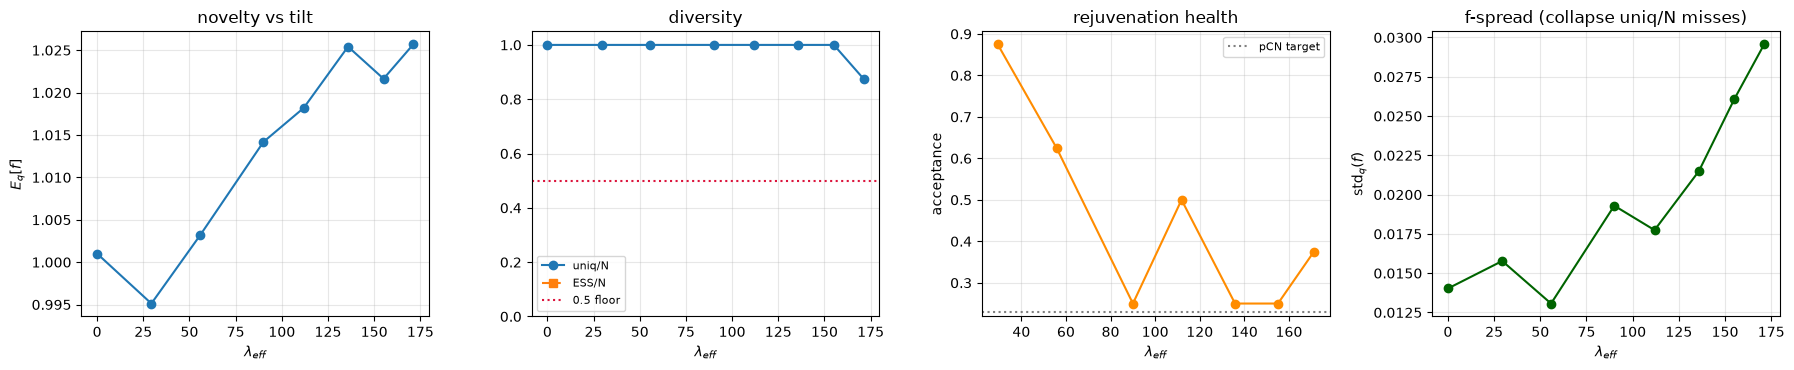

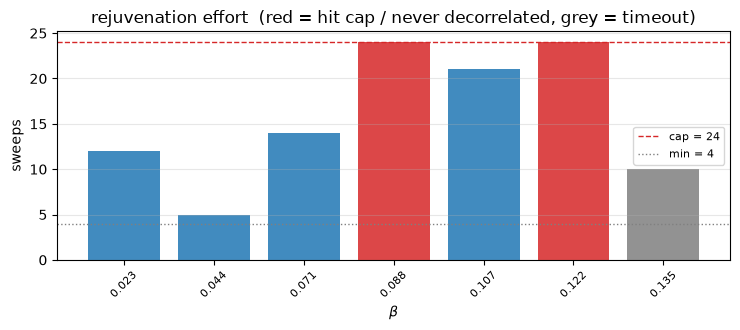

In [6]:
# --- results table --------------------------------------------------------------------------------
lam_eff = [l.lam_eff for l in levels]
Eqf = [float(l.fX.mean()) for l in levels]
f_sd = [float(l.fX.std()) for l in levels]
uniq = [int(l.X.unique(dim=0).shape[0]) / N for l in levels]
# ess_history holds RAW ESS counts in [1, N]; normalize to compare against the 0.5 floor.
ess = [float("nan")] + [float(e) / N for e in res.ess_history]
acc = [float("nan")] + [float(a) for a in res.acc_history]
sweeps = [0] + list(res.n_mcmc_history)
stops = ["-"] + list(res.stop_reason_history)
base_f = Eqf[0]

print(f"betas               = {[round(b, 4) for b in res.betas]}")
print(f"n_mcmc_history      = {res.n_mcmc_history}   (total {sum(res.n_mcmc_history)} sweeps)")
print(f"stop_reason_history = {res.stop_reason_history}")
print(f"\n{'k':>2} {'beta':>7} {'lam_eff':>9} {'m':>6} {'E_q[f]':>8} {'d f':>8} {'d f/sd':>7} "
      f"{'ESS/N':>6} {'acc':>6} {'uniq/N':>7} {'f-sd':>8} {'swp':>4} {'stop':>8}")
for k in range(len(levels)):
    print(f"{k:2d} {levels[k].beta:7.4f} {lam_eff[k]:9.1f} {lam_eff[k] / lam_s:6.2f} "
          f"{Eqf[k]:8.4f} {Eqf[k] - base_f:+8.4f} {(Eqf[k] - base_f) / f_sd[0]:7.1f} "
          f"{ess[k]:6.2f} {acc[k]:6.2f} {uniq[k]:7.2f} {f_sd[k]:8.4f} {sweeps[k]:4d} {stops[k]:>8}")

print(f"\nnovelty gain: E_q[f] {base_f:.4f} -> {Eqf[-1]:.4f} "
      f"({100 * (Eqf[-1] / base_f - 1):+.1f}%, {(Eqf[-1] - base_f) / f_sd[0]:.1f} sigma_p(f))")
print(f"baseline (m=3) reached +4.3% = 2.1 sigma; beta reached {levels[-1].beta:.4f} of 1.0")
n_cap = sum(1 for r in res.stop_reason_history if r == "cap")
print(f"levels hitting the sweep cap ({MAX_SWEEPS}): {n_cap}/{len(res.stop_reason_history)}")

# --- diagnostics ----------------------------------------------------------------------------------
fig, ax = plt.subplots(1, 4, figsize=(18, 3.8))
ax[0].plot(lam_eff, Eqf, "o-"); ax[0].set_ylabel(r"$E_q[f]$")
ax[0].set_title("novelty vs tilt")
ax[1].plot(lam_eff, uniq, "o-", label="uniq/N")
ax[1].plot(lam_eff, ess, "s--", label="ESS/N")
ax[1].axhline(0.5, color="crimson", ls=":", label="0.5 floor")
ax[1].set_ylim(0, 1.05); ax[1].legend(fontsize=8); ax[1].set_title("diversity")
ax[2].plot(lam_eff, acc, "o-", color="darkorange")
ax[2].axhline(0.23, color="grey", ls=":", label="pCN target")
ax[2].set_ylabel("acceptance"); ax[2].legend(fontsize=8); ax[2].set_title("rejuvenation health")
ax[3].plot(lam_eff, f_sd, "o-", color="darkgreen")
ax[3].set_ylabel(r"std$_q(f)$"); ax[3].set_title("f-spread (collapse uniq/N misses)")
for a in ax:
    a.set_xlabel(r"$\lambda_{eff}$"); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

fig, a = plt.subplots(figsize=(7.5, 3.4))
cols = ["tab:red" if r == "cap" else "tab:grey" if r == "timeout" else "tab:blue"
        for r in res.stop_reason_history]
a.bar(range(len(res.betas)), res.n_mcmc_history, color=cols, alpha=0.85)
a.axhline(MAX_SWEEPS, ls="--", color="tab:red", lw=1, label=f"cap = {MAX_SWEEPS}")
a.axhline(4, ls=":", color="grey", lw=1, label="min = 4")
a.set_xticks(range(len(res.betas)))
a.set_xticklabels([f"{b:.3f}" for b in res.betas], rotation=45, fontsize=8)
a.set_xlabel(r"$\beta$"); a.set_ylabel("sweeps"); a.legend(fontsize=8); a.grid(alpha=0.3, axis="y")
a.set_title("rejuvenation effort  (red = hit cap / never decorrelated, grey = timeout)")
plt.tight_layout(); plt.show()

decoded 8 levels x 8 particles


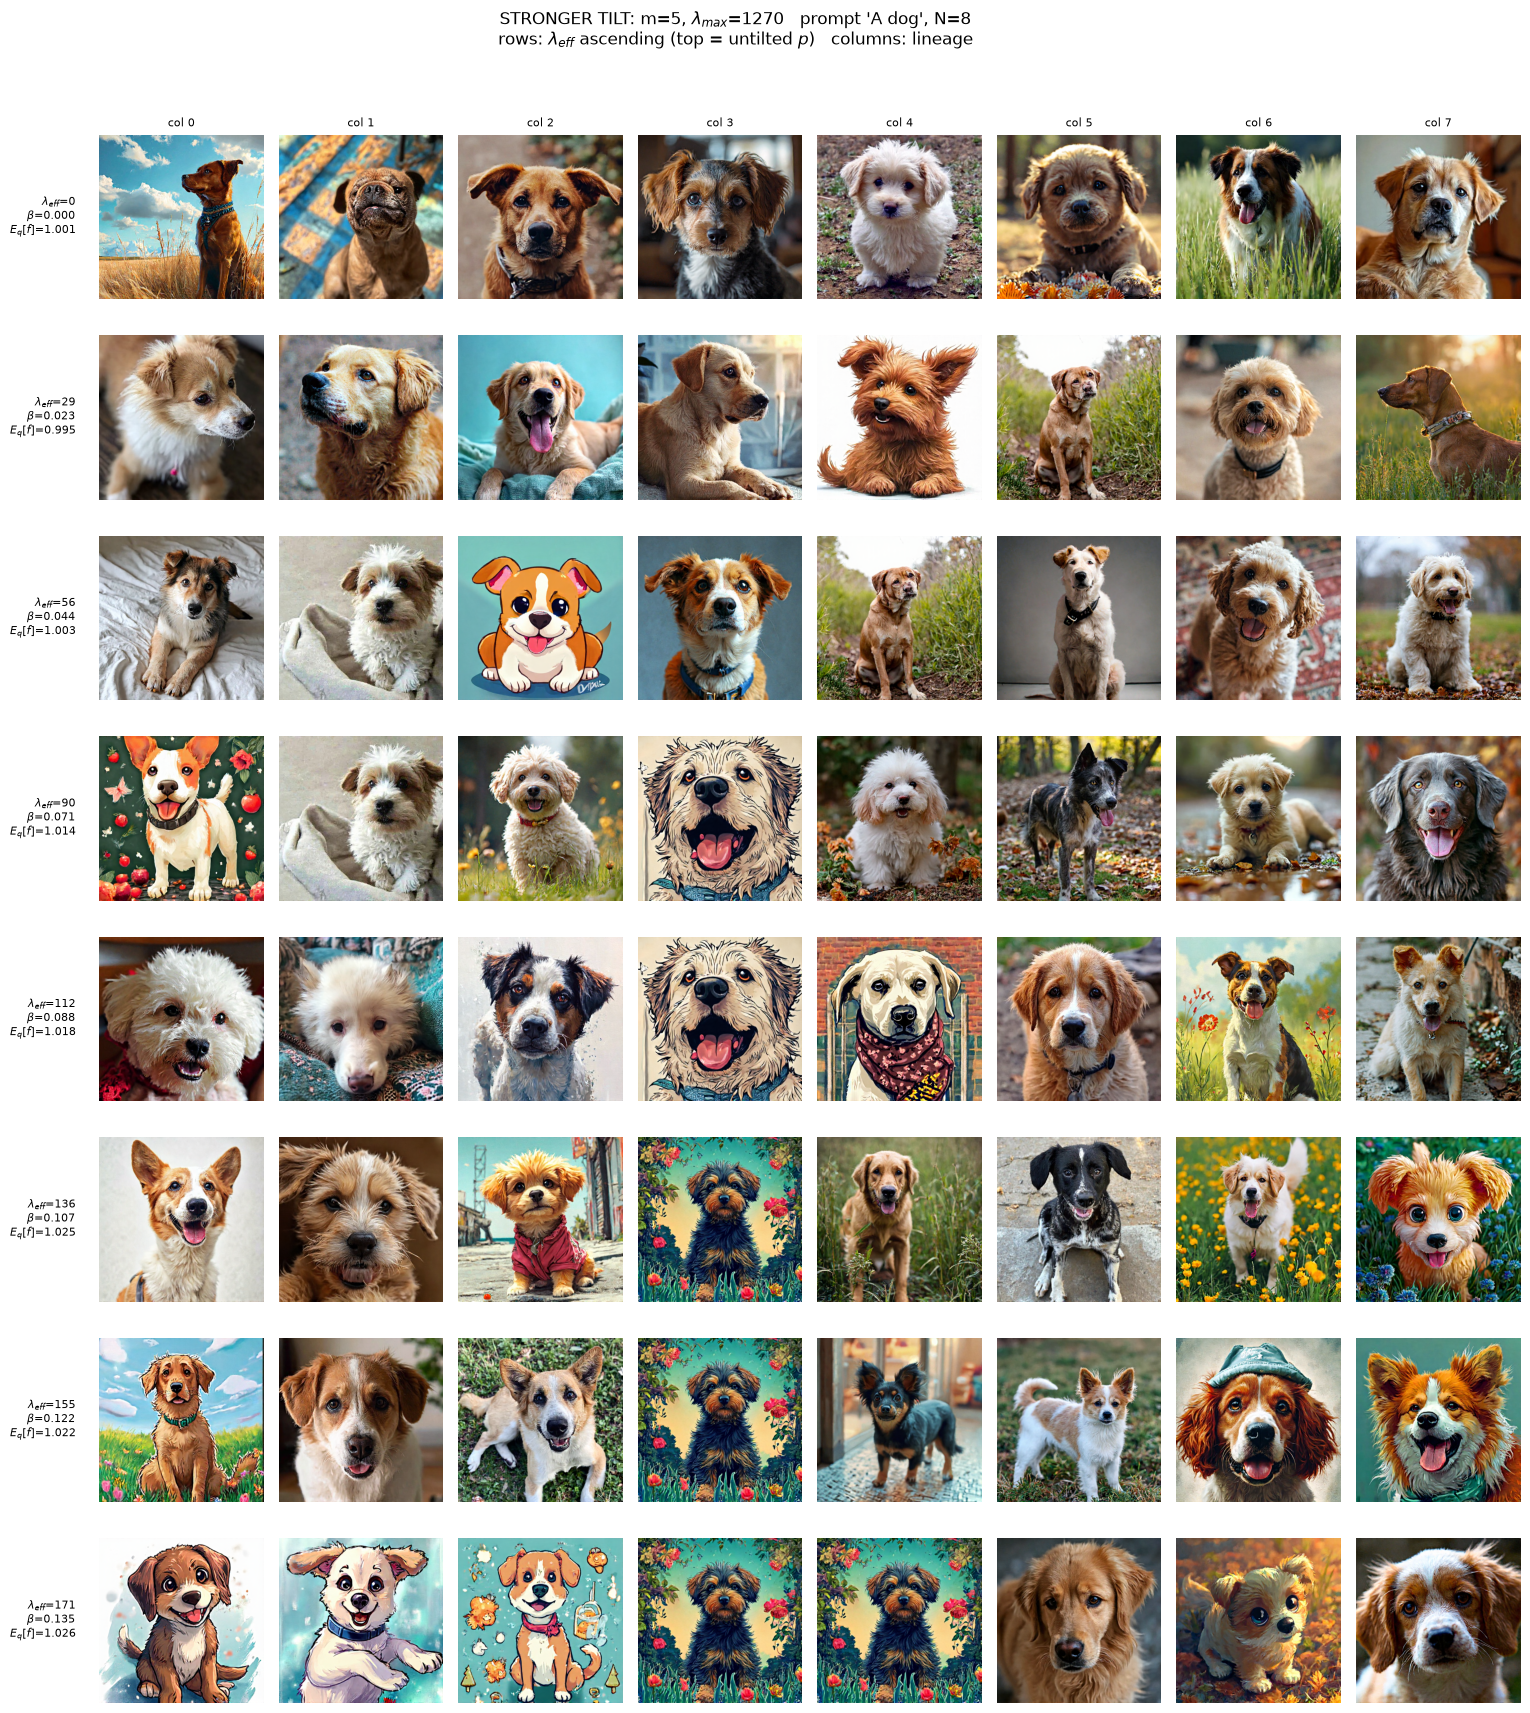

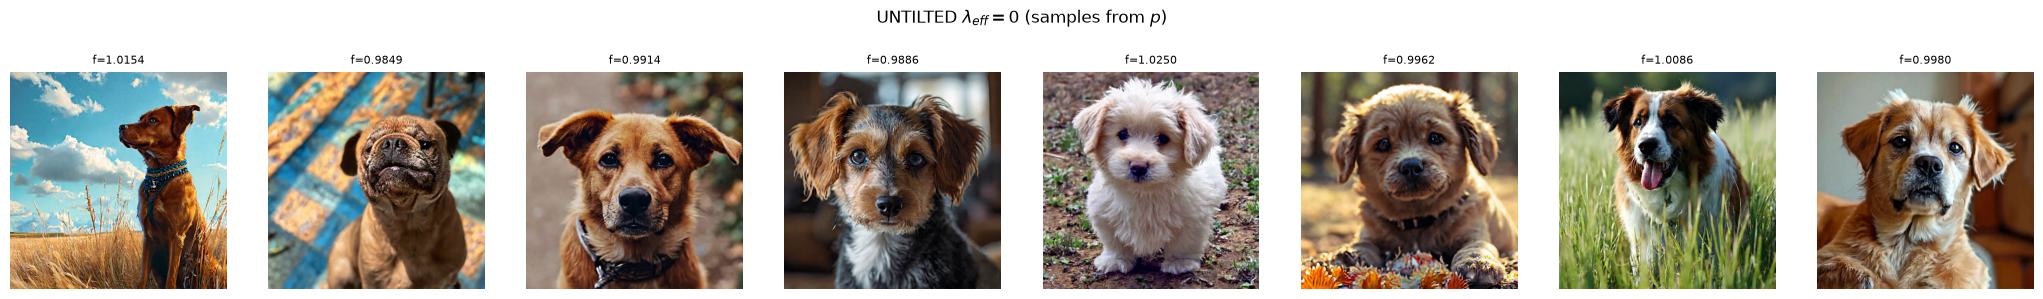

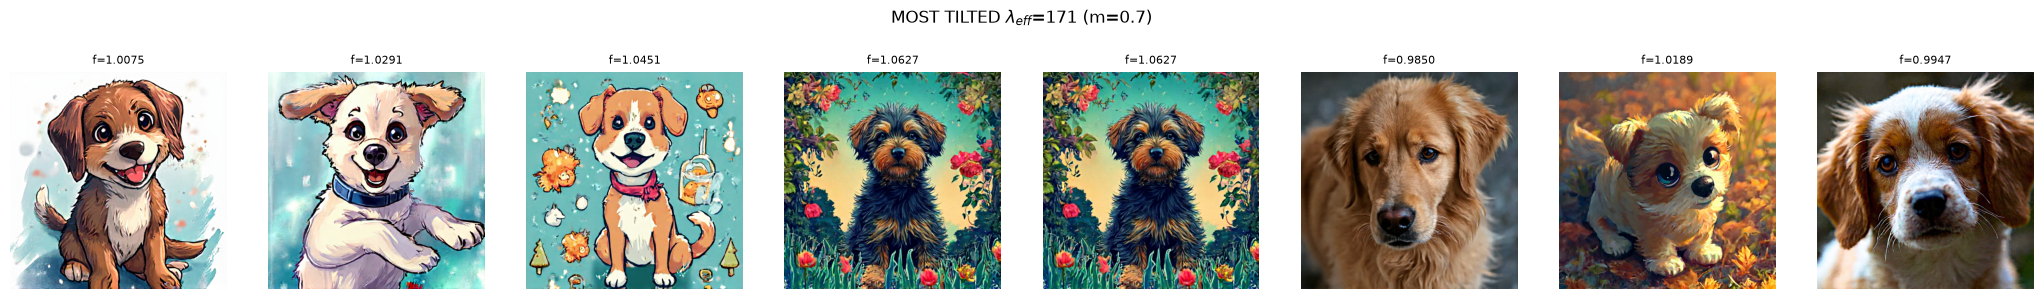

wrote 64 PNGs to decoded/ and strong_tilt_grid.png


In [7]:
# --- images ---------------------------------------------------------------------------------------
# Columns ordered by LINEAGE: walk `ancestors` backwards from the final level, so a column tracks one
# particle as the tilt strengthens. Repeated images across a row are resampler coalescence, which is
# information, not a defect. (On a timed-out run ancestors are arange, so this reduces to raw order.)
col_of = [None] * len(levels)
cur = torch.arange(N)
col_of[-1] = cur
for k in range(len(levels) - 1, 0, -1):
    cur = levels[k].ancestors[cur]
    col_of[k - 1] = cur

decoded = [decode(l.X[col_of[k]]) for k, l in enumerate(levels)]
print(f"decoded {len(levels)} levels x {N} particles")

nrow = len(levels)
fig, axes = plt.subplots(nrow, N, figsize=(N * 2.0, nrow * 2.2), squeeze=False)
for k in range(nrow):
    for j in range(N):
        a = axes[k][j]
        a.axis("off")
        a.imshow(decoded[k][j].permute(1, 2, 0).clamp(0, 1).numpy())
        if j == 0:
            a.text(-0.14, 0.5, f"$\\lambda_{{eff}}$={lam_eff[k]:.0f}\n$\\beta$={levels[k].beta:.3f}\n"
                               f"$E_q[f]$={Eqf[k]:.3f}",
                   transform=a.transAxes, ha="right", va="center", fontsize=8)
        if k == 0:
            a.set_title(f"col {j}", fontsize=8)
fig.suptitle(f"STRONGER TILT: m={M_TILT:.0f}, $\\lambda_{{max}}$={LAM_MAX:.0f}   "
             f"prompt {PROMPT!r}, N={N}\nrows: $\\lambda_{{eff}}$ ascending (top = untilted $p$)   "
             f"columns: lineage", fontsize=12)
plt.tight_layout(rect=(0.04, 0, 1, 0.965))
plt.show()
fig.savefig(os.path.join(SWEEP_DIR, "strong_tilt_grid.png"), dpi=140, bbox_inches="tight")

# Untilted anchor vs most tilted, enlarged, for a direct visual read on what the tilt did.
for k, label in ((0, "UNTILTED $\\lambda_{eff}=0$ (samples from $p$)"),
                 (len(levels) - 1, f"MOST TILTED $\\lambda_{{eff}}$={lam_eff[-1]:.0f} "
                                   f"(m={lam_eff[-1] / lam_s:.1f})")):
    fig, axes = plt.subplots(1, N, figsize=(N * 2.6, 3.0), squeeze=False)
    for j in range(N):
        a = axes[0][j]
        a.axis("off")
        a.imshow(decoded[k][j].permute(1, 2, 0).clamp(0, 1).numpy())
        a.set_title(f"f={float(levels[k].fX[col_of[k][j]]):.4f}", fontsize=8)
    fig.suptitle(label, fontsize=12)
    plt.tight_layout(rect=(0, 0, 1, 0.93)); plt.show()

# Per-image PNGs for full-resolution inspection.
from PIL import Image

os.makedirs(os.path.join(SWEEP_DIR, "decoded"), exist_ok=True)
for k in range(len(levels)):
    for j in range(N):
        arr = (decoded[k][j].permute(1, 2, 0).clamp(0, 1) * 255).round().to(torch.uint8).numpy()
        Image.fromarray(arr).save(
            os.path.join(SWEEP_DIR, "decoded", f"lvl{k:02d}_lam{lam_eff[k]:.0f}_col{j}.png"))
print(f"wrote {len(levels) * N} PNGs to decoded/ and strong_tilt_grid.png")

## Takeaways

**The question.** The baseline (FLUX.1-dev, `GUIDANCE` 3.5, $m = 3$) reached $\approx 2.1\sigma$ in $f$ yet produced clean,
ordinary dogs at every level. Three explanations were live: the tilt was too weak, the base density $p$ was too narrow
for the tilt to have anywhere to go, or $f$ itself does not track visible novelty at `R=4, N_GAMMA=6, NUM_EPS=3`.
This run attacked the first two together (`GUIDANCE` 3.5 $\to$ 1.5, $m$ 3 $\to$ 5).

**Verdict: it never got to a strong tilt. What it did deliver is an answer to the third hypothesis.**

---

### 1. The run tests $m \approx 0.7$, not $m = 5$ — the $\beta$ schedule is the bottleneck

|  | predicted (cell 4) | actual |
| --- | --- | --- |
| truncation $\beta$ | 0.57 | **0.135** |
| $\lambda_{\text{eff}}$ reached | $\approx 2.8\sigma$ | **171**, i.e. $m_{\text{eff}} = 0.67$ (of `LAM_MAX` = 1270) |
| levels to $\beta = 1$ | 8.3 | **$\approx 52$** |

Truncation was expected; its severity was not. The cell-4 cost model projected levels-to-$\beta = 1$ from $\lambda_{s}$
alone, implicitly assuming $\beta$ steps of $\approx 0.12$. The ESS rule actually produced steps of
0.023, 0.021, 0.027, 0.017, 0.019, 0.015, 0.013 — mean 0.019 and **shrinking**.

**The binding constraint is the adaptive $\beta$ schedule, not the 24-sweep rejuvenation cap.** Extrapolating the
observed rate, $\beta = 1$ needs $\approx 816$ sweeps $\approx 38$ GPU-hours — about $6\times$ the 6 h budget.
The cost model must be rebuilt around the observed $\Delta\beta$ per level; predicting it from $\lambda_{s}$ does not work.

Sweep cost also came in above estimate: 165 s per sweep-equivalent ($G$ + reward, batch 8) against the baseline's 115 s.
Lower guidance did not make the ODE cheaper.

### 2. "$p$ was too narrow" is falsified — and in the opposite direction

The prediction was that if guidance was the constraint, a wider $p$ would show a **larger** $\operatorname{std}_{p}(f)$
than the baseline's 0.0203. It measured **0.0039 — roughly $5\times$ smaller**. Dropping guidance to 1.5 made $f$
*tighter* under $p$, not wider.

**But that number does not replicate.** The level-0 ensemble — also 8 draws from $p$ — gives
$\operatorname{std} = 0.0140$, a **$3.6\times$ disagreement** with the 8-sample probe
(probe range $[0.9836, 0.9939]$ vs level-0 range $[0.9849, 1.0250]$). Consequences:

- $\lambda_{s} = 254$ is uncertain by $\approx 3\times$; `LAM_MAX` is not "$5\sigma$" in any defensible sense.
- Every $\sigma$-unit figure in the results table (which normalises by the level-0 0.0140, not the probe 0.0039)
  inherits that ambiguity.

**Re-estimating $\lambda_{s}$ on many more than 8 probe samples is a prerequisite for the next run.** The whole
$\lambda$ ladder, and the $m$ column, rest on it.

### 3. The reward's first axis of novelty is *rendering style*, not structure

This is the substantive finding.

- **Row 0 is recognisably ordinary photographic dogs.** Guidance 1.5 widened $p$ without breaking it — the
  "went too far" check passes, and the comparison is about a freer $p$, not a different one.
- From $\lambda_{\text{eff}} \approx 90$ upward the ensemble moves clearly toward **illustration, cartoon, and
  vector/decorative rendering** (bottom rows, cols 0–3). The baseline at $m = 3$ produced no visible movement at all.

So $f$ at `R=4, N_GAMMA=6, NUM_EPS=3` **does** track something visible, and what it tracks is
photographic $\to$ illustrated: a texture/rendering direction, not semantic or structural novelty of the subject.

**Corollary: $\Delta f / \sigma$ is a bad progress metric.** The baseline moved $+4.3\%$ in $f$ ($2.1\sigma$) with no
visible change; this run moved $+2.5\%$ ($1.8\sigma$) with obvious change. Smaller movement in $f$, larger
perceptual movement. Novelty in $f$ and novelty to the eye came apart, so neither $E_{q}[f]$ nor its $\sigma$-normalised
version can be used to decide whether a run "worked".

#### Cross-check against the 2D study (`demo_properties.ipynb`, Exp 1–3)

**Correction — the $\gamma$ window is weighted the opposite way from a raw $d\gamma$ count.** A first pass here
weighted the intervals by their share of $\int d\gamma$ and concluded the fine-detail end dominates. That ignores the
integrand's own $\gamma$-dependence. Conclusion 1b of the 2D study gives it: in the high-$\gamma$ (geometry) regime the
integrand factorises as $\frac{1}{\gamma^{2}}\|\nabla \log p_{X}(x_{1}) - \nabla \log p_{X}(x_{2})\|^{2}$, so the real
per-interval contribution is $\int d\gamma / \gamma^{2}$, not $\int d\gamma$. For this run's grid
(`logspace(0.95, 1024, 6)`, $\sigma = 1/\sqrt{\gamma}$, data scale $S = 1.026$) the two weightings are exact mirrors:

| $\gamma$ interval | [0.95, 3.84] | [3.84, 15.5] | [15.5, 62.7] | [62.7, 253] | [253, 1024] |
| --- | --- | --- | --- | --- | --- |
| $\sigma$ range | 1.03–0.51 | 0.51–0.25 | 0.25–0.13 | 0.13–0.063 | 0.063–0.031 |
| share of $\int d\gamma$ (wrong measure) | 0.3% | 1.1% | 4.6% | 18.6% | 75.3% |
| **share of $\int d\gamma/\gamma^{2}$ (Concl. 1b)** | **75.3%** | 18.6% | 4.6% | 1.1% | 0.3% |

**The reward is dominated by the *lowest* $\gamma$ interval, not the highest** — and that is the interval sitting right
on the Euclidean floor. Conclusion 1a: as $\gamma \to 0$ the integrand degenerates to plain squared Euclidean distance
$\|x_{1} - x_{2}\|^{2}$, and the tilt merely "pushes the density away".

So the mechanism behind the style finding is plausibly the *opposite* of the first reading: not only fine-detail texture
sensitivity, but $f$ mainly operating near the Euclidean-floor regime, where it behaves partly like plain latent-space distance
from the references — and "push away in latent space" is a credible driver of global appearance change rather than
semantic change. It is possible that after the distribution has been "pushed away" hard enough, the the $f$ values of the lower-
noise parts will take an even more dominant part.

**Quadrature — quantified, and the current grid is far below the calibrated value.** Conclusion 2 of the 2D study finds
$f$ converges for $N_{\gamma} \ge 25$ and adopts 50, and argues the requirement should transfer to high $d$ because
$N_{\gamma}$ resolves a *one-dimensional* integral over $\gamma$, independent of the data dimension. **This run used
$N_{\gamma} = 6$.** With one rectangle spanning $\Delta\gamma = 770$ and the true weight concentrated at the other end
of the window, the current grid cannot resolve either regime. This is a concrete, calibrated deficiency rather than a
vague caveat, and it is a confound for the style finding independent of everything else.

**On the confound.** Two variables moved, so a positive result is in principle ambiguous — but the ambiguity resolves
*toward guidance*: this run reached a strictly **lower** effective tilt than the baseline ($0.67\sigma$ vs $2.1\sigma$)
and still produced more visible change. The mechanism is not the predicted one, though: $\operatorname{std}_{p}(f)$ went
down, not up, so whatever guidance 1.5 freed up is not captured by the spread of $f$ under $p$.

### 4. From level 3 onward the sampler is not mixing — those rows are not draws from $q_{\lambda}$

- **`ESS/N` is `nan` at every level.** In general, lambda is an inverse temperature parameter that should be choosen by eyeballing.
  If trying to use a numerical selection rule, we might attempt to choose the largest $\lambda$ whose min ESS/N and `uniq/N`
  stay above $\approx 0.5$. The current diagnosticbug won't allow that and should be fixed befor any further FLUX runs.
- **Acceptance pins at 0.25**, the pCN target floor, from $\lambda_{\text{eff}} = 90$ on, with 2 of 7 levels burning the
  full 24-sweep cap without reaching the decorrelation threshold. The kernel has stopped decorrelating.
- **`uniq/N` finally breaks.** It reads 1.00 as usual (known untrustworthy) until the last level, where it drops to 0.88 —
  and the grid confirms it: **cols 3 and 4 of the bottom row are identical**. Real ancestry collapse is now visible.
- Rising $f$-spread (0.0140 $\to$ 0.0296) is the one healthy-looking signal, but under a stuck kernel it reads as
  particles drifting apart without equilibrating rather than as exploration.

Treat levels 3–7 as "where the chain got to", not as samples from $q_{\lambda_{\text{eff}}}$.

### 5. What to do next

Keep guidance 1.5 — row 0 is still valid $p$ and the tilt finally bites. Before spending another 6 h:

1. Fix the `nan` `ESS/N` in the diagnostics.
2. Re-estimate $\lambda_{s}$ with many more probe samples (N); the 8-sample estimate is not usable.
3. **Bring the IEM knobs up to the 2D-calibrated settings before drawing further conclusions about what $f$ measures.**
   Two of the three are currently off-spec, and both push in the same direction (toward the Euclidean floor):
   - **$N_{\gamma}$: 6 $\to$ at least 25** (Concl. 2). Cheapest fix, dimension-independent justification.
4. **Only then** treat $R$ / $\gamma$ / distance as steering controls over *which* axis of novelty $f$ points along.
   With "$f$ is inert" falsified, that is what they are — but the current settings are off-calibration enough that the
   style result may be an artefact of the coarse grid and the small numder of references rather than a property of the IEM.

**Caveats carried over.** Rows share ancestry and are not independent draws from $q_{\lambda_{\text{eff}}}$;
$\lambda_{\text{eff}}$ values are chosen by the ESS rule, not by us; $N = 8$ throughout, so every ensemble statistic
here is noisy; and `uniq/N` can read 1.00 for a collapsed ensemble because pCN moves duplicated particles apart.
The 2D conclusions imported above were derived on a 2D GMM where the $\gamma \to \infty$ factorisation and the
$B(t) \sim t^{2}$ barrier are partly Gaussian artefacts; `demo_properties.ipynb` argues the mechanisms are definitional
(Tweedie / posterior covariance) and should transfer, but that has not been verified on FLUX latents.
